# Exploring data sources for ERA5

Brian Rose, June 17 2026

## Our prepackaged example data

We have 12 hours of hourly sea level pressure data extracted from ERA5

In [1]:
import xarray as xr

In [2]:
ds = xr.open_dataset("data/SLP_ex.nc")
da = ds["SLP"]
da

<xarray.DataArray 'SLP' (time: 13, latitude: 181, longitude: 360)> Size: 7MB
[847080 values with dtype=float64]
Coordinates:
  * time       (time) datetime64[ns] 104B 2022-11-01 ... 2022-11-01T12:00:00
  * latitude   (latitude) float32 724B 90.0 89.0 88.0 87.0 ... -88.0 -89.0 -90.0
  * longitude  (longitude) float32 1kB 0.0 1.0 2.0 3.0 ... 357.0 358.0 359.0
Attributes:
    standard_name:  air_pressure_at_mean_sea_level
    long_name:      Mean sea level pressure
    units:          Pa

### A reference plot

Just plot the first time step

In [3]:
ref_time = da.time[0]

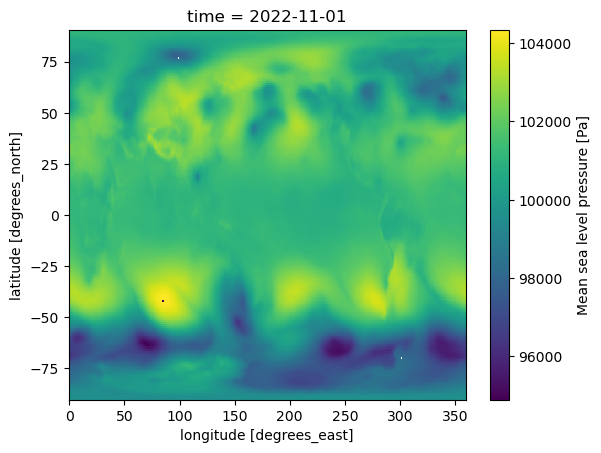

In [4]:
da.sel(time=ref_time).plot()

## Streaming ERA5 data from Earthmover

This requires a per-user login (need to create a free account in advance)

But we can easily recreate the same data slice and the same reference plot.

In [5]:
from arraylake import Client
client = Client()

In [6]:
client.login()

Successfully refreshed tokens! Token stored at /Users/brianrose/.arraylake/token.json

╭───────────────────────────────────────────────── User Details ──────────────────────────────────────────────────╮
│ Name: None None                                                                                                 │
│ Email: brose@albany.edu                                                                                         │
│ Id: 42b3a5b8-e618-4e14-aba8-632532f16692                                                                        │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

In [7]:
repo = client.get_repo("earthmover-public/era5")
session = repo.readonly_session("main")

In [8]:
ds_spatial = xr.open_zarr(session.store, group="single/spatial", chunks=None)

This has grabbed a live handle to a really vast amount of data:

In [9]:
ds_spatial

<xarray.Dataset> Size: 110TB
Dimensions:     (valid_time: 753888, latitude: 721, longitude: 1440)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 6MB 1940-01-01 ... 2025-12-31T23:...
  * latitude    (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude   (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
    lsm         (latitude, longitude) float32 4MB ...
Data variables: (12/35)
    blh         (valid_time, latitude, longitude) float32 3TB ...
    cape        (valid_time, latitude, longitude) float32 3TB ...
    cp          (valid_time, latitude, longitude) float32 3TB ...
    d2m         (valid_time, latitude, longitude) float32 3TB ...
    fsr         (valid_time, latitude, longitude) float32 3TB ...
    fg10        (valid_time, latitude, longitude) float32 3TB ...
    ...          ...
    u100        (valid_time, latitude, longitude) float32 3TB ...
    tsr         (valid_time, latitude, longitude) float32 3TB ...
    tcwv        (valid_time, latitude, longitude) float32 3TB ...
    v100        (valid_time, latitude, longitude) float32 3TB ...
    v10         (valid_time, latitude, longitude) float32 3TB ...
    zust        (valid_time, latitude, longitude) float32 3TB ...
Attributes: (12/46)
    Conventions:                CF-1.7
    title:                      ERA5 Hourly Global Reanalysis - chunked for s...
    summary:                    ERA5 is the fifth generation ECMWF atmospheri...
    keywords:                   ERA5, reanalysis, atmosphere, climate, ECMWF,...
    keywords_vocabulary:        GCMD Science Keywords
    id:                         era5
    ...                         ...
    proj:code:                  EPSG:4326
    proj:epsg:                  4326
    GRIB_centre:                ecmf
    GRIB_centreDescription:     European Centre for Medium-Range Weather Fore...
    GRIB_subCentre:             0
    history:                    2026-05-10T20:01 GRIB to CDM+CF via cfgrib-0....

The sea level pressure data is in here in variable `msl`:

In [10]:
ds_spatial.msl.GRIB_cfName

'air_pressure_at_mean_sea_level'

We can easily subset the exact same slice of sea level pressure data as our pre-loaded file:

In [11]:
ds_spatial.msl.sel(valid_time=da.time)

<xarray.DataArray 'msl' (time: 13, latitude: 721, longitude: 1440)> Size: 54MB
[13497120 values with dtype=float32]
Coordinates:
  * time        (time) datetime64[ns] 104B 2022-11-01 ... 2022-11-01T12:00:00
    valid_time  (time) datetime64[ns] 104B 2022-11-01 ... 2022-11-01T12:00:00
  * latitude    (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude   (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
    lsm         (latitude, longitude) float32 4MB ...
Attributes: (12/32)
    GRIB_paramId:                             151
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      1038240
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_units:                               Pa
    long_name:                                Mean sea level pressure
    units:                                    Pa
    standard_name:                            air_pressure_at_mean_sea_level
    GRIB_surface:                             0.0

### Recreate the reference plot, this time from streamed data

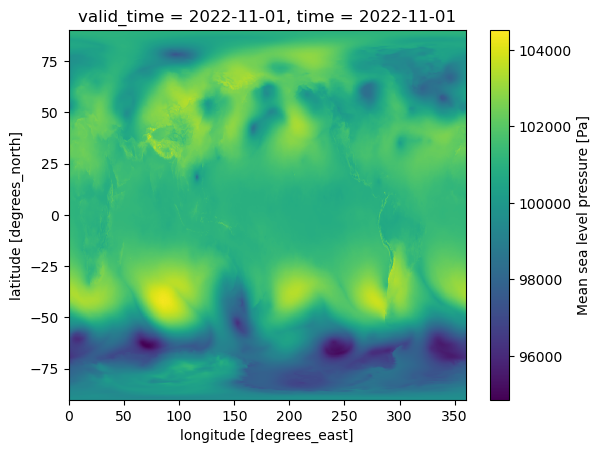

In [12]:
ds_spatial.msl.sel(valid_time=ref_time).plot()